# Neutron reflectometry use

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from reflectorch import InferenceModel, Layer, Structure, Backing, EXP_DATA_DIR
from reflectorch.inference.plotting import print_prediction_results, plot_reflectivity

torch.manual_seed(0); # set seed for reproducibility

In this tutorial, we build upon the concepts introduced in the previous tutorial, where we demonstrated inference on XRR data, by highlighting key considerations specific to NR data.

## Handling linear resolution smearing

We consider the following NR data for a 1-layer stucture of Ni on Si (air as ambient), measured at a resolution dq/q = 0.1 (i.e. 10%):

In [2]:
data = np.loadtxt(EXP_DATA_DIR / 'Ni500.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())

(174, 3)
(174,) (174,) 0.01333 0.22399
(174,) 8.83715e-05 4.23214e-07 0.3282606076124776


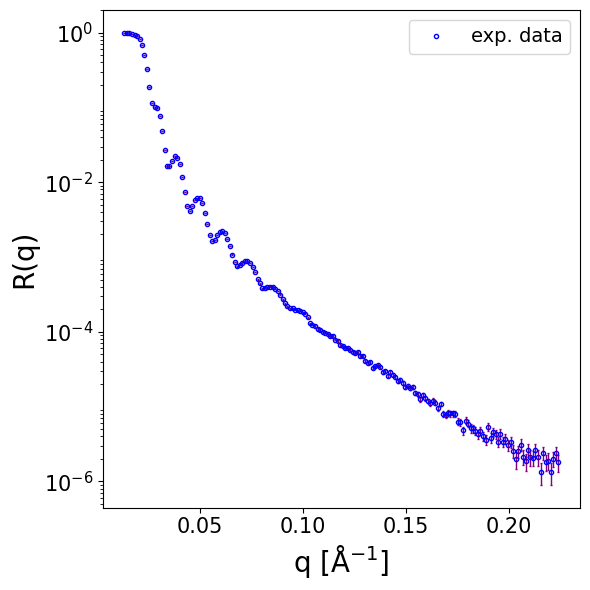

In [3]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, 
    r_exp=curve_exp,
    yerr=sigmas_exp,
)

We initialize an inference object for a model trained for neutron reflectometry and a standard parameterization with 1 layer (for more details on the `InferenceModel` class see the previous tutorial). Notably, the parameterization has 2 additional nuisance parameters: a scaling factor for the intensity of the reflectivity curve and the constant backround (in log10 representation). Here we load the models from the ['reflectorch-ILL'](https://huggingface.co/reflectorch-ILL) Huggingface repository which is a repository for selected NR models mainly targeting use cases relevant at the Institut Laue-Langevin (ILL), as opposed to the default research-based Huggingface repository ['valentinsingularity/reflectivity'](https://huggingface.co/valentinsingularity/reflectivity/tree/main).

In [4]:
config_name = "NR-1layer-basic-v1"

inference_model = InferenceModel(
    config_name=config_name,
    repo_id="reflectorch-ILL",
    device='cpu',
)

Configuration file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/configs/NR-1layer-basic-v1.yaml` not found locally.
Weights file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/saved_models/model_NR-1layer-basic-v1.safetensors` found locally.
Model NR-1layer-basic-v1 loaded. Number of parameters: 21.90 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained with linear resolution smearing (dq/q) in the range [0.01, 0.12]
The following quantities are additional inputs to the network: prior bounds, the resolution dq/q.


We set some prior bounds for the parameters:

In [5]:
prior_bounds = [
    (300., 900.), #layer thicknesses (top to bottom)

    (0., 20.), #interlayer roughnesses (top to bottom)
    (0., 20.), 
                
    (9., 11.), #real layer slds: Ni, glass
    (3., 5.),

    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
]

For performing the prediction we need to provide the `q_resolution` argument. When this argument is a *float*, its meaning is dq/q. This value is always used for simulating the reflectivity curve corresponding to the predicted parameters and as a keyword argument to the reflectivity function during polishing. Depending on the training scenario, it might also be used as an additional input to the network. 

Since NR data can have points with high error bars which can disturb the neural network prediction, the `preprocess_and_predict` method can filter out the points with high error bars for the purpose of the prediction (they are still used for the polishing step), if the array of error bars (`sigmas`) is provided and `enable_error_bars_filtering` is `True`. Then the points where the error bar to intensity ratio is higher than the `filter_threshold` argument will be removed before the neural network inference. One can also manually truncate the part of the data seen by the network via the `truncate_index_left` and `truncate_index_right` arguments. 

In [6]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    q_resolution=0.1,
    sigmas=sigmas_exp,
    clip_prediction=True,
    polish_prediction=True,
    use_sigmas_for_polishing=False,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.3,
    sld_profile_padding_right=1.3,

    enable_error_bars_filtering=True,
    filter_threshold=0.3,
    truncate_index_left=None,
    truncate_index_right=None,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict.get('polished_curve')
q_plot = prediction_dict['q_plot_pred']

In [7]:
print_prediction_results(prediction_dict)

Parameter          Predicted    Polished
----------------------------------------
Thickness L1         498.954     497.006
Roughness L1           6.429       6.504
Roughness sub          6.793       7.226
SLD L1                 9.939      10.232
SLD sub                3.138       3.415
r_scale                0.944       0.977
log10_background      -7.238      -6.277


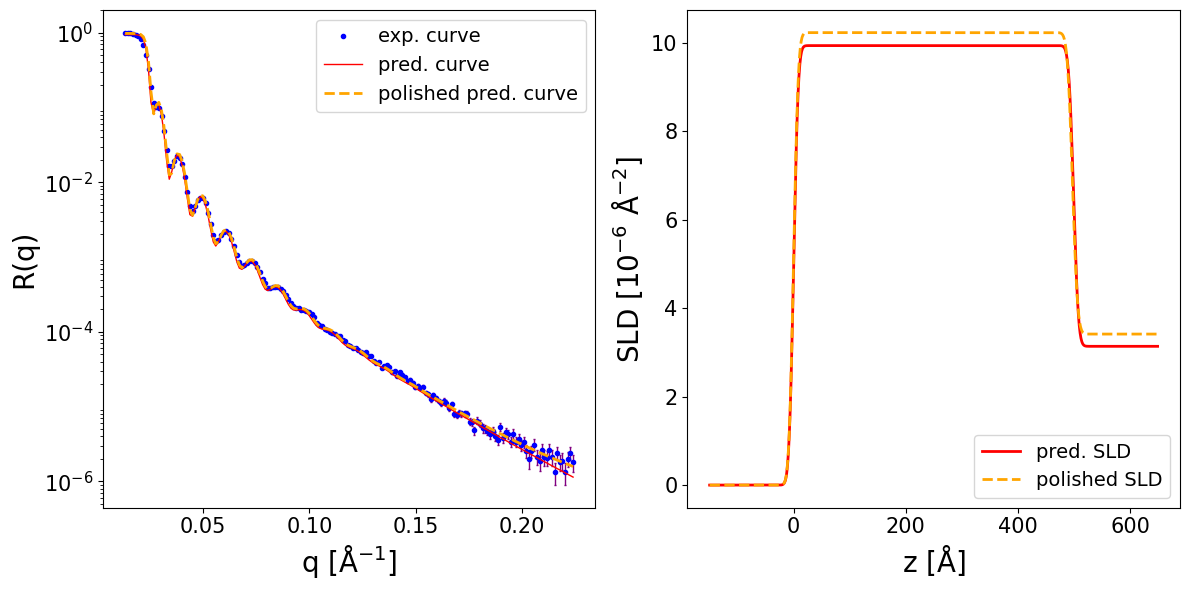

In [8]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp, exp_style='errorbar', exp_marker='o', exp_ms=3,  exp_color='blue', exp_facecolor='blue', exp_alpha=1.0, exp_label='exp. curve', exp_zorder=1,
    yerr=sigmas_exp, xerr=None, exp_errcolor='purple', exp_elinewidth=1.0, exp_capsize=1, exp_capthick=1.0,
    q_pred=q_plot, r_pred=pred_curve, pred_color='red', pred_lw=1.0, pred_ls='-', pred_label='pred. curve', pred_alpha=1.0, pred_zorder=2,
    q_pol=q_exp, r_pol=polished_curve, pol_color='orange', pol_lw=2.0, pol_ls='--', pol_label='polished pred. curve', pol_alpha=1.0, pol_zorder=3,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'], sld_pred_color='red', sld_pred_lw=2.0, sld_pred_ls='-', sld_pred_label='pred. SLD',
    sld_pol=prediction_dict['sld_profile_polished'], sld_pol_color='orange', sld_pol_lw=2.0, sld_pol_ls='--', sld_pol_label='polished SLD',
)

Next, we load data for a different measurement of a similar structure (also Ni on Si). The differences are that the Ni layer is thicker, the resolution is dq/q = 0.015 (i.e. 1.5 %) and the data has a constant background.

In [9]:
data = np.loadtxt(EXP_DATA_DIR / 'Ni_on_glass.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())


(757, 2)
(757,) (757,) 0.00508981 0.175655


In [10]:
prior_bounds = [
    (300., 900.), #layer thicknesses (top to bottom)

    (0., 20.), #interlayer roughnesses (top to bottom)
    (0., 20.), 

    (9., 11.), #layer slds: Ni, glass
    (3., 5.), 

    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
]

:::{tip}
:class: dropdown

Alternatively, one can define the prior bounds in the following manner:


```python
Ni_layer = Layer(thickness_bounds=(300, 900), roughness_bounds=(0, 20), sld_bounds=(9, 11))
backing = Backing(roughness_bounds=(0, 20), sld_bounds=(3, 5))

structure = Structure(
    layers=[Ni_layer, backing],
    r_scale_bounds=(0.9, 1.1),
    log10_background_bounds=(-10, -4),
)

prior_bounds = structure.prior_bounds
```

:::

Now we provide the new value of dq/q as argument:

In [11]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    q_resolution=0.015,
    sigmas=None,
    clip_prediction=True,
    polish_prediction=True,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.3,
    sld_profile_padding_right=1.3,

    truncate_index_left=None,
    truncate_index_right=None,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict.get('polished_curve')
q_plot = prediction_dict['q_plot_pred']

In [12]:
print_prediction_results(prediction_dict, precision=2)

Parameter          Predicted    Polished
----------------------------------------
Thickness L1          831.42      827.32
Roughness L1           10.53        8.52
Roughness sub           1.55        0.00
SLD L1                  9.05        9.19
SLD sub                 4.39        3.91
r_scale                 0.98        0.91
log10_background       -4.00       -4.00


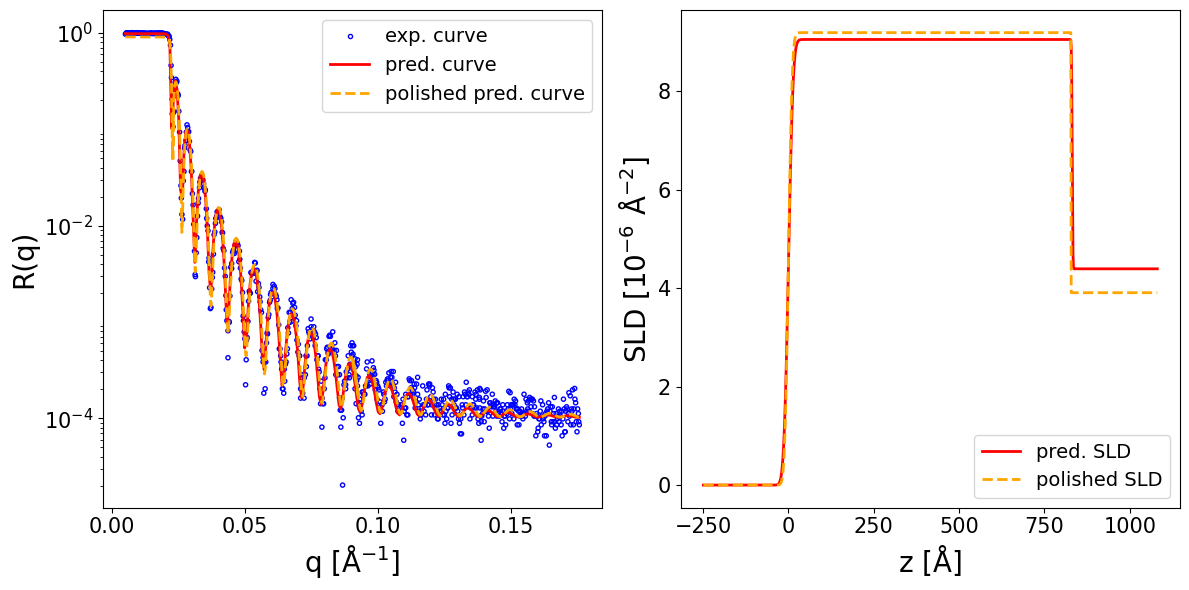

In [13]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp, exp_style='scatter', exp_marker='o', exp_ms=3,  exp_color='blue', exp_facecolor='none', exp_alpha=1.0, exp_label='exp. curve', exp_zorder=1,
    yerr=None,
    q_pred=q_plot, r_pred=pred_curve, pred_color='red', pred_lw=2.0, pred_ls='-', pred_label='pred. curve', pred_alpha=1.0, pred_zorder=2,
    q_pol=q_exp, r_pol=polished_curve, pol_color='orange', pol_lw=2.0, pol_ls='--', pol_label='polished pred. curve', pol_alpha=1.0, pol_zorder=3,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'], sld_pred_color='red', sld_pred_lw=2.0, sld_pred_ls='-', sld_pred_label='pred. SLD',
    sld_pol=prediction_dict['sld_profile_polished'], sld_pol_color='orange', sld_pol_lw=2.0, sld_pol_ls='--', sld_pol_label='polished SLD',
)

## Handling pointwise resolution smearing

We load NR data of a thick silicon oxide layer on top of a silicon substrate. Notably the data is in 4 colums format [q, R, dR, dQ], the last column being the pointwise resolution smearing.

In [14]:
data = np.loadtxt(EXP_DATA_DIR / 'D17_SiO.dat', skiprows=3)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]
q_res_exp = data[..., 3]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min())
print(q_res_exp.shape, (q_res_exp / q_exp).min(), (q_res_exp / q_exp).max())

(2166, 4)
(2166,) (2166,) 0.00610735 0.277902
(2166,) 1.39997 4.75674e-07
(2166,) 0.01295813163759255 0.020793481155227386


In [15]:
config_name = "NR-1layer-basic-v1"

inference_model = InferenceModel(
    config_name=config_name,
    repo_id="reflectorch-ILL",
    device='cpu',
)

Configuration file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/configs/NR-1layer-basic-v1.yaml` found locally.
Weights file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/saved_models/model_NR-1layer-basic-v1.safetensors` found locally.
Model NR-1layer-basic-v1 loaded. Number of parameters: 21.90 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained with linear resolution smearing (dq/q) in the range [0.01, 0.12]
The following quantities are additional inputs to the network: prior bounds, the resolution dq/q.


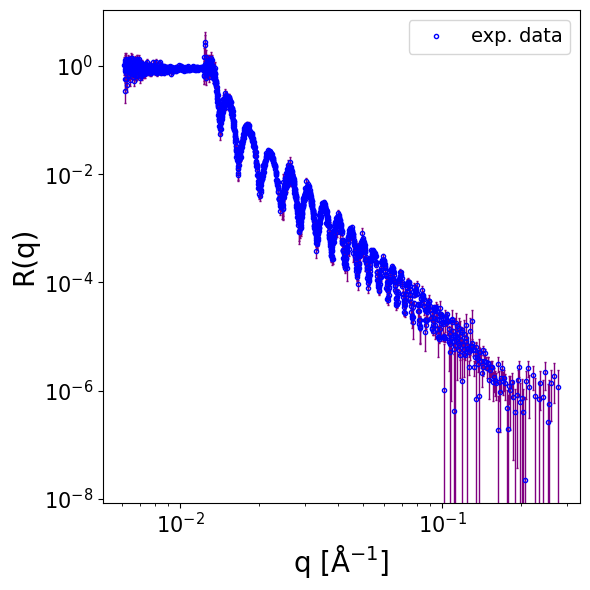

In [16]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, 
    r_exp=curve_exp,
    yerr=sigmas_exp,
    logx=True,
)

In [17]:
prior_bounds = [
    (500., 1500.), #layer thicknesses (top to bottom)

    (0., 30.), #interlayer roughnesses (top to bottom)
    (0., 30.),
    
    (3, 4), #layer slds (top to bottom)
    (1.7, 2.5), 
    
    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

In [18]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    q_resolution=q_res_exp,
    sigmas=sigmas_exp,
    clip_prediction=True,
    polish_prediction=True,
    use_sigmas_for_polishing=True,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.3,
    sld_profile_padding_right=1.3,

    enable_error_bars_filtering=True,
    filter_threshold=0.3,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict.get('polished_curve')
q_plot = prediction_dict['q_plot_pred']

In [19]:
print_prediction_results(prediction_dict)

Parameter          Predicted    Polished
----------------------------------------
Thickness L1        1246.756    1244.731
Roughness L1           5.675       3.070
Roughness sub          4.594       0.007
SLD L1                 3.536       3.473
SLD sub                2.207       2.198
r_scale                0.903       0.934
log10_background      -5.929      -6.561


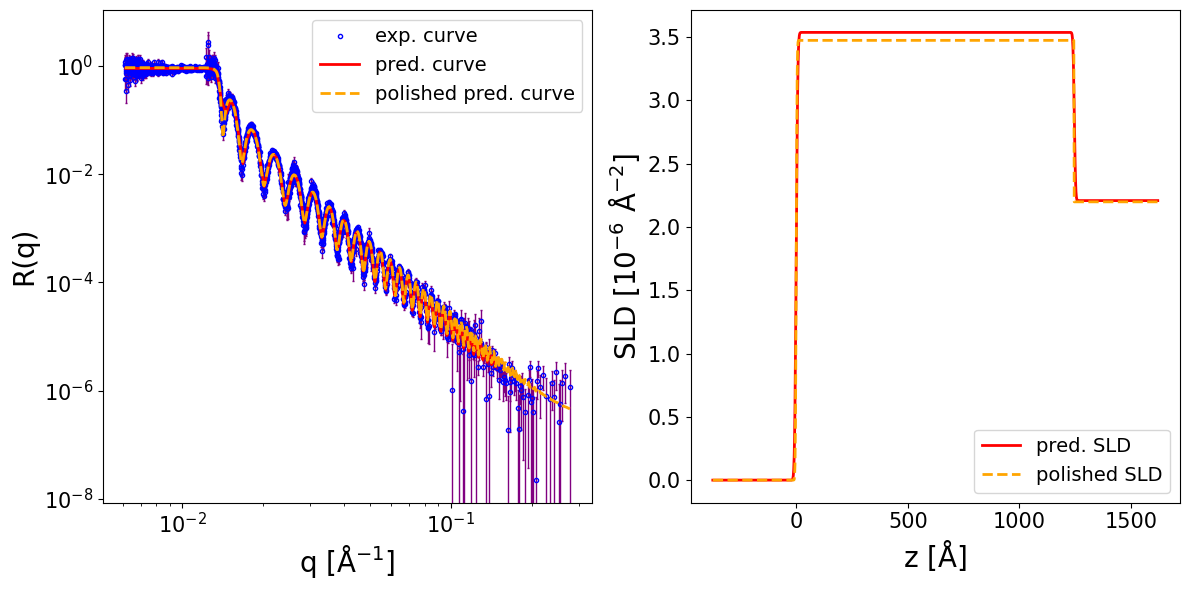

In [20]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp, exp_style='errorbar', exp_marker='o', exp_ms=3,  exp_color='blue', exp_facecolor='none', exp_alpha=1.0, exp_label='exp. curve', exp_zorder=1,
    yerr=sigmas_exp, xerr=None, exp_errcolor='purple', exp_elinewidth=1.0, exp_capsize=1, exp_capthick=1.0,
    q_pred=q_plot, r_pred=pred_curve, pred_color='red', pred_lw=2.0, pred_ls='-', pred_label='pred. curve', pred_alpha=1.0, pred_zorder=2,
    q_pol=q_exp, r_pol=polished_curve, pol_color='orange', pol_lw=2.0, pol_ls='--', pol_label='polished pred. curve', pol_alpha=1.0, pol_zorder=3,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'], sld_pred_color='red', sld_pred_lw=2.0, sld_pred_ls='-', sld_pred_label='pred. SLD',
    sld_pol=prediction_dict['sld_profile_polished'], sld_pol_color='orange', sld_pol_lw=2.0, sld_pol_ls='--', sld_pol_label='polished SLD',

    logx=True,
)


## Structures with fronting medium different than air

We load neutron reflectometry (NR) data for a multilayer structure composed of silicon/silicon oxide/polymer/D₂O. Notably, the fronting medium in this case is not air, meaning the fronting SLD is non-zero. Although all models in Reflectorch are trained assuming a fronting SLD of zero, inference on data with non-zero fronting SLD is still valid. This is due to the invariance property of reflectivity under uniform SLD shifts, where R(SLD(z)) = R(SLD(z)+A) for any constant A.

In [21]:
data = np.loadtxt(EXP_DATA_DIR / 'ORSO_example.ort')
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]
q_res_exp = data[..., 3]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())
print(q_res_exp.shape, (q_res_exp / q_exp).min(), (q_res_exp / q_exp).max())

(408, 4)
(408,) (408,) 0.00806022 0.465555
(408,) 0.125959 1.19257e-07 1.784325740151806
(408,) 0.017461305621930916 0.020605159300190096


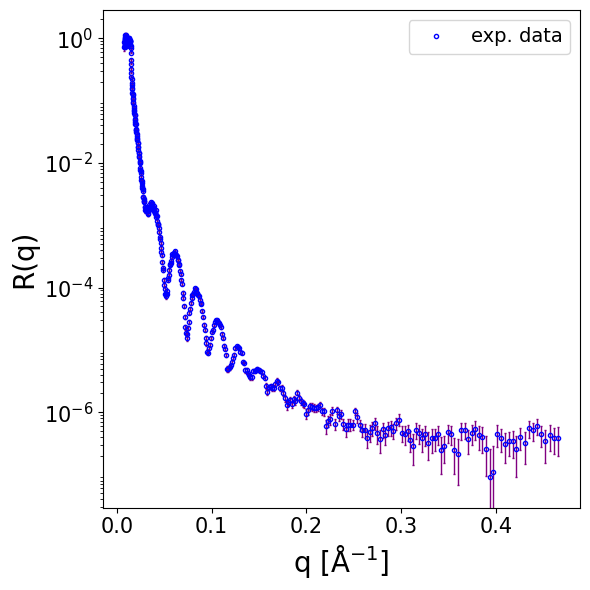

In [22]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, 
    r_exp=curve_exp,
    yerr=sigmas_exp,
)

In [23]:
config_name = "NR-2layers-basic-v1"

inference_model = InferenceModel(
    config_name=config_name,
    repo_id="reflectorch-ILL",
    device='cpu',
)

Configuration file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/configs/NR-2layers-basic-v1.yaml` not found locally.
Weights file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/saved_models/model_NR-2layers-basic-v1.safetensors` found locally.
Model NR-2layers-basic-v1 loaded. Number of parameters: 22.00 M
The model corresponds to a `standard_model` parameterization with 2 layers (10 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained with linear resolution smearing (dq/q) in the range [0.01, 0.12]
The following quantities are additional inputs to the network: prior bounds, the resolution dq/q.


In [24]:
prior_bounds = [
    (10., 40.), #layer thicknesses: SiOx, polymer
    (50., 500.), 
    
    (1.0, 20.0), #interlayer roughnesses: Si/SiOx, SiOx/polymer, polymer/D2O
    (1.0, 20.0), 
    (1.0, 20.0), 

    (2.5, 4.0), #layer slds: SiOx, polymer, D2O
    (1., 5.), 
    (6.3, 6.4),

    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

For inference we need to additionally provide the SLD of the fronting medium (here silicon) as the `ambient_sld` argument of the `preprocess_and_predict` method:

In [25]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    q_resolution=q_res_exp,
    sigmas=sigmas_exp,
    ambient_sld=2.07, #Si
    clip_prediction=True,
    polish_prediction=True,
    use_sigmas_for_polishing=False,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.3,
    sld_profile_padding_right=1.3,

    enable_error_bars_filtering=True,
    filter_threshold=0.3,
    truncate_index_left=None,
    truncate_index_right=None,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict.get('polished_curve')
q_plot = prediction_dict['q_plot_pred']

In [26]:
print_prediction_results(prediction_dict)

Parameter          Predicted    Polished
----------------------------------------
Thickness L1          33.265      37.770
Thickness L2         261.801     259.244
Roughness L1           6.719       7.671
Roughness L2           6.727      10.235
Roughness sub          3.454       3.143
SLD L1                 3.402       3.521
SLD L2                 2.367       2.438
SLD sub                6.320       6.342
r_scale                0.900       0.900
log10_background      -6.424      -6.471


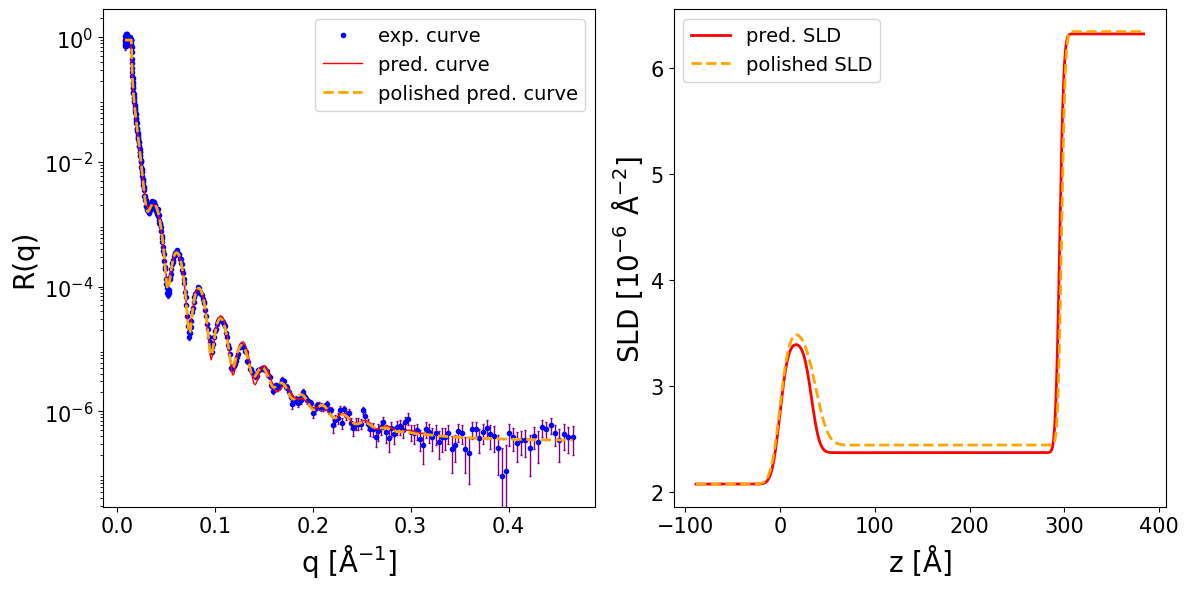

In [27]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp, exp_style='errorbar', exp_marker='o', exp_ms=3,  exp_color='blue', exp_facecolor='blue', exp_alpha=1.0, exp_label='exp. curve', exp_zorder=1,
    yerr=sigmas_exp, xerr=None, exp_errcolor='purple', exp_elinewidth=1.0, exp_capsize=1, exp_capthick=1.0,
    q_pred=q_plot, r_pred=pred_curve, pred_color='red', pred_lw=1.0, pred_ls='-', pred_label='pred. curve', pred_alpha=1.0, pred_zorder=2,
    q_pol=q_exp, r_pol=polished_curve, pol_color='orange', pol_lw=2.0, pol_ls='--', pol_label='polished pred. curve', pol_alpha=1.0, pol_zorder=3,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'], sld_pred_color='red', sld_pred_lw=2.0, sld_pred_ls='-', sld_pred_label='pred. SLD',
    sld_pol=prediction_dict['sld_profile_polished'], sld_pol_color='orange', sld_pol_lw=2.0, sld_pol_ls='--', sld_pol_label='polished SLD',
)